# Tutorial: sc-linker via cellink
**Integrating single-cell RNA-seq, epigenomics and GWAS to identify disease-critical cell types**

sc-linker was developed by [Jagadeesh et al. 2022](https://www.nature.com/articles/s41588-022-01187-9). sc-linker first generates gene programs  (genes × cell_types, scores in [0,1]) from scRNA-seq data. It then generates bedgraphs using enhancer activity and a 100kb window. These bedgraphs are intersected with SNP annotations. LDSC is then used for heritability estimation. The interpretable result is the E-score, which is the difference of the nrichment of the gene program and the enrichment of a control. Use > 50 donors for the scRNA-seq and a well-powered GWAS.

## Environment

sc-linker requires an installation of bedtools, e.g. via [conda](https://anaconda.org/channels/bioconda/packages/bedtools/overview) (conda install bioconda::bedtools).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import scanpy as sc
from cellink.resources import get_dummy_onek1k
from cellink.resources import (
    get_1000genomes_ld_scores,
    get_1000genomes_ld_weights,
    get_1000genomes_plink_files,
    get_1000genomes_frq,
    get_1000genomes_hapmap3,
)
from cellink.tl.external import (
    configure_ldsc_runner,
    estimate_heritability,
    munge_sumstats,
    compute_ld_scores_with_annotations_from_bimfile,
)
from cellink.tl.external import (
    compute_celltype_programs,
    compute_diseaseprogression_programs,
    compute_nmf_programs,
    compute_joint_nmf_programs,
)
from cellink.tl.external import (
    download_sclinker_enhancer_links,
    load_roadmap_links,
    load_abc_links,
    load_gene_annotation,
    genescores_to_annotations,
    compute_ld_scores_for_sclinker,
    load_sclinker_heritability_results,
    compute_escore,
    run_sclinker_heritability,
)

dd = get_dummy_onek1k(
    config_path="../../src/cellink/resources/config/dummy_onek1k.yaml",
    verify_checksum=False,
)
print(f"Dataset: {dd.shape}")
print(f"Cell types: {dd.C.obs['predicted.celltype.l2'].unique()[:5]}")

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_pgen/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[2026-04-08 20:25:16,140] INFO:root: /home/icb/lucas.arnoldt/cellink_data/dummy_onek1k/dummy_onek1k.dd.h5 already exists
[2026-04-08 20:25:16,141] WARNING:root: No checksum provided, skipping verification
[2026-04-08 20:25:20,497] INFO:root: Loaded dummy OneK1K dataset: (100, 146939, 125366, 34073)
Dataset: (100, 146939, 125366, 34073)
Cell types: ['gdT', 'NK', 'CD8 TEM', 'CD4 Naive', 'CD4 TCM']
Categories (31, object): ['ASDC', 'B intermediate', 'B memory', 'B naive', ..., 'cDC2', 'dnT', 'gdT', 'pDC']


## Configure the LDSC runner

cellink runs LDSC through a **Singularity** container via `LDSCRunner`.

In [2]:
runner = configure_ldsc_runner(config_dict={
    "execution_mode":    "singularity",
    "singularity_image": "/home/icb/lucas.arnoldt/workspace/projects/ldsc.sif",

    "ldsc_command":       "/ldsc/ldsc.py",
    "make_annot_command": "/ldsc/make_annot.py",
    "munge_command":      "/ldsc/munge_sumstats.py",

    "parse_script": "/ldsc/ldscore/parse.py",

    "singularity_patch_strategy": "overlay",
})

## Download reference files

### 1a: 1000 Genomes LD scores, weights and PLINK files

cellink already has helpers in `cellink.resources._1000genomes` that
download and cache the 1000G files. We use those directly instead of
calling `gsutil` manually.

In [3]:
_cfg = "../../src/cellink/resources/config/1000genomes.yaml"

ld_scores_dir, ld_prefix = get_1000genomes_ld_scores(population="EUR", return_path=True, config_path=_cfg)
print(f"LD scores  : {ld_scores_dir}  (prefix: {ld_prefix})")

ld_weights_dir, weights_prefix = get_1000genomes_ld_weights(population="EUR", return_path=True, config_path=_cfg)
print(f"LD weights : {ld_weights_dir}  (prefix: {weights_prefix})")

plink_dir, plink_prefix = get_1000genomes_plink_files(population="EUR", config_path=_cfg)
print(f"PLINK      : {plink_dir}  (prefix: {plink_prefix})")

frq_dir, frq_prefix = get_1000genomes_frq(population="EUR", config_path=_cfg)
print(f"Frq files  : {frq_dir}  (prefix: {frq_prefix})")

hapmap3_snps = get_1000genomes_hapmap3(config_path=_cfg)
print(f"HapMap3    : {hapmap3_snps}")

ref_ld_chr = str(ld_scores_dir  / ld_prefix)    
w_ld_chr   = str(ld_weights_dir / weights_prefix) 
bim_prefix = str(plink_dir      / plink_prefix)   
frq_chr    = str(frq_dir        / frq_prefix)  

print(f"\nref_ld_chr : {ref_ld_chr}")
print(f"w_ld_chr   : {w_ld_chr}")
print(f"bim_prefix : {bim_prefix}")
print(f"frq_chr    : {frq_chr}")

[2026-04-08 20:25:20,766] INFO:root: /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_scores_EUR/1000G_Phase3_baselineLD_v2.2_ldscores.tgz already exists
[2026-04-08 20:25:20,767] WARNING:root: No checksum provided, skipping verification
LD scores  : /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_scores_EUR  (prefix: baselineLD.)
[2026-04-08 20:25:20,797] INFO:root: /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_weights_EUR/1000G_Phase3_weights_hm3_no_MHC.tgz already exists
[2026-04-08 20:25:20,797] WARNING:root: No checksum provided, skipping verification
LD weights : /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_weights_EUR  (prefix: weights.hm3_noMHC.)
[2026-04-08 20:25:20,811] INFO:root: /home/icb/lucas.arnoldt/cellink_data/1000genomes_plink_EUR/1000G_Phase3_plinkfiles.tgz already exists
[2026-04-08 20:25:20,812] WARNING:root: No checksum provided, skipping verification
PLINK      : /home/icb/lucas.arnoldt/cellink_data/1000genomes_plink_EUR  (prefix: 1000G.EUR.QC

### 1b: sc-linker enhancer-gene links and gene coordinates

These files are not part of the standard 1000G bundle — they come from the
Broad sc-linker server and are specific to this pipeline.

In [7]:
# Roadmap, ABC, and gene_annotation.txt are downloaded via HTTPS from GCS.
# Source: https://storage.googleapis.com/broad-alkesgroup-public/LDSCORE/Jagadeesh_Dey_sclinker/extras/
#
# Files downloaded per tissue:
#   Roadmap_{tissue}_E.txt.gz
#   ABCpaper_NasserFulcoEngreitz2020_{tissue}_AvgHiC.txt.gz
#   gene_annotation.txt  (shared across tissues, downloaded once)
#
# Available tissues: BLD BRN GI LNG LIV KID SKIN FAT HRT
enhancer_refs = download_sclinker_enhancer_links(
    out_dir="sclinker_refs",
    tissue="BLD",
)
print(enhancer_refs)

[2026-04-08 20:43:33,416] INFO:cellink.tl.external._sclinker_utils: Already exists, skipping: sclinker_refs/RoadmapUABCannot_regions_to_genes.txt.gz
[2026-04-08 20:43:33,475] INFO:cellink.tl.external._sclinker_utils: Already exists, skipping: sclinker_refs/AllPredictions.AvgHiC.ABC0.015.minus150.withcolnames.ForABCPaper.txt.gz
[2026-04-08 20:43:33,475] INFO:cellink.tl.external._sclinker_utils: Already exists, skipping: sclinker_refs/Roadmap_map_EID_names.txt
[2026-04-08 20:43:33,476] INFO:cellink.tl.external._sclinker_utils: sc-linker enhancer files in sclinker_refs: ['roadmap', 'abc', 'roadmap_eid']
{'roadmap': PosixPath('sclinker_refs/RoadmapUABCannot_regions_to_genes.txt.gz'), 'abc': PosixPath('sclinker_refs/AllPredictions.AvgHiC.ABC0.015.minus150.withcolnames.ForABCPaper.txt.gz'), 'roadmap_eid': PosixPath('sclinker_refs/Roadmap_map_EID_names.txt')}


## Gene programs

### 2a: Cell-type programs

In [8]:
counts = dd.C.obs["predicted.celltype.l2"].value_counts()

TOP_N = 5
top_celltypes = counts.head(TOP_N).index
adata = dd.C[dd.C.obs["predicted.celltype.l2"].isin(top_celltypes)].copy()
print(f"Using {TOP_N} cell types: {top_celltypes.tolist()}")
print(f"Cells: {adata.n_obs:,}")

# If var_names are ENSG IDs (e.g. ENSG00000...), the Roadmap/ABC TargetGene
# column uses HGNC names, so there will be a mismatch.
if adata.var_names.str.startswith("ENSG").mean() > 0.5:
    if "gene_name" not in adata.var.columns:
        for col in ["gene_names", "feature_name", "gene_symbol", "Symbol"]:
            if col in adata.var.columns:
                adata.var["gene_name"] = adata.var[col]
                print(f"Using adata.var['{col}'] as gene_name")
                break
        else:
            print("var_names are ENSG IDs — querying BioMart for HGNC mapping ...")
            from cellink.tl.external import get_gene_annotation
            gene_coord = get_gene_annotation(gene_id_type="ensembl")
            import pandas as _pd
            ensg2hgnc = _pd.read_csv(gene_coord, sep=" ")[["GENE"]].copy()
            hgnc_coord = get_gene_annotation(gene_id_type="hgnc")
            from pathlib import Path
            from cellink.resources._utils import get_data_home
            ensembl_f = get_data_home() / "gene_coord_ensembl.txt"
            hgnc_f    = get_data_home() / "gene_coord_hgnc.txt"
            if ensembl_f.exists() and hgnc_f.exists():
                from cellink.tl.external._sldsc_utils import _query_biomart_and_write_gene_coords
                _query_biomart_and_write_gene_coords(get_data_home())
            print("  Done. HGNC names will be applied automatically in compute_celltype_programs.")
    else:
        print("adata.var['gene_name'] already present — will map ENSG→HGNC automatically")

print(f"var_names sample: {adata.var_names[:3].tolist()}")

ct_programs = compute_celltype_programs(
    adata,
    celltype_col="predicted.celltype.l2",
    out_dir="gene_programs/celltype",
    save=True,
)
genescores = ct_programs["genescores"]
print(f"Gene programs: {genescores.shape}")
print(f"Index sample (should be HGNC): {genescores.index[:5].tolist()}")

Using 5 cell types: ['CD4 TCM', 'CD4 Naive', 'CD8 TEM', 'NK', 'B naive']
Cells: 93,886
Using adata.var['feature_name'] as gene_name
var_names sample: ['ENSG00000284662', 'ENSG00000229905', 'ENSG00000237491']
[2026-04-08 20:43:41,867] INFO:cellink.tl.external._sclinker: Running rank_genes_groups for predicted.celltype.l2 (93886 cells after filtering)


... storing 'donor_id' as categorical
... storing 'chrom' as categorical


[2026-04-08 20:44:57,975] INFO:cellink.tl.external._sclinker: Mapped var_names from ENSG IDs to HGNC gene names using adata.var['gene_name']. This is required for matching against Roadmap/ABC TargetGene columns.
[2026-04-08 20:44:58,615] INFO:cellink.tl.external._sclinker: Saved cell-type program matrices to gene_programs/celltype
Gene programs: (34073, 5)
Index sample (should be HGNC): ['C1orf115_ENSG00000162817', 'SCNN1B_ENSG00000168447', 'ENSG00000225794.3', 'TIFAB_ENSG00000255833', 'ANKRD23_ENSG00000163126']


### 2b: Disease-progression programs (requires matched healthy/disease data)

In [6]:
# Uncomment and adapt when you have an AnnData with both healthy and disease cells.
#
# disease_programs = compute_diseaseprogression_programs(
#     adata_disease,
#     celltype_col="cell_type",
#     diagnosis_col="disease_status",
#     healthy_label="Healthy",
#     disease_label="Disease",
#     out_dir="gene_programs/disease",
#     save=True,
# )

### 2c: NMF cellular process programs

If you have a GPU available, you may install `torchnmf` via `pip install torchnmf`. Alternatively the scikit-learn NMF implementation is used, which is substantially slower. 

In [7]:
W, H, corr = compute_nmf_programs(
    adata,
    celltype_col="predicted.celltype.l2",
    out_dir="gene_programs/nmf",
    save=True,
    device="cuda",   # change to "cpu" if no GPU available
)
nmf_genescores = corr.clip(lower=0)
print(f"NMF programs: cells={W.shape}, genes={H.shape}")

[2026-04-08 16:08:18,220] INFO:cellink.tl.external._sclinker: Setting n_components = 5 cell types + 10 = 15


[2026-04-08 16:08:30,832] INFO:cellink.tl.external._sclinker: Fitting NMF with 15 components on (93886, 34073) matrix
[2026-04-08 16:09:35,348] INFO:cellink.tl.external._sclinker: torchnmf: using GPU (NVIDIA A100 80GB PCIe)


/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_pgen/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


NMF programs: cells=(93886, 15), genes=(34073, 15)


### 2d: AllCoding control program

sc-linker always runs an "all protein-coding genes" control alongside every
program. The E-score subtracts the AllCoding enrichment:

    E-score(program, trait) = Enrichment(program) − Enrichment(AllCoding)

We add it as an extra column so it goes through the same annotation and
LD score pipeline automatically.

In [8]:
gene_annot = load_gene_annotation(gene_id_type="hgnc", refresh=True)
print(f"Gene annotations: {len(gene_annot):,} unique genes")

# AllCoding control: every protein-coding gene gets score 1
all_coding = pd.DataFrame(
    np.ones(len(gene_annot)),
    index=gene_annot["GENE"].str.upper(),
    columns=["AllCoding"],
)
all_coding = all_coding[~all_coding.index.duplicated(keep="first")]

all_genescores = pd.concat([genescores, all_coding], axis=1).fillna(0)
all_genescores = all_genescores[~all_genescores.index.duplicated(keep="first")]
print(f"Programs including AllCoding: {all_genescores.shape[1]} total")
print(f"Unique genes: {all_genescores.shape[0]:,}")

[2026-04-08 16:10:39,940] INFO:cellink.tl.external._sclinker_utils: Querying Ensembl BioMart for human gene coordinates ...
[2026-04-08 16:10:40,485] INFO:cellink.tl.external._sclinker_utils: BioMart returned 78,691 gene entries
[2026-04-08 16:10:40,813] INFO:cellink.tl.external._sclinker_utils: Wrote 78,691 unique ENSG entries → gene_coord_ensembl.txt
[2026-04-08 16:10:40,907] INFO:cellink.tl.external._sclinker_utils: Wrote 41,417 unique HGNC entries → gene_coord_hgnc.txt
[2026-04-08 16:10:40,924] INFO:cellink.tl.external._sclinker_utils: Loaded 41,417 gene coordinates (gene_id_type='hgnc') from gene_coord_hgnc.txt
Gene annotations: 41,417 unique genes
Programs including AllCoding: 6 total
Unique genes: 69,390


## Step 2: Gene programs -> SNP annotations

This creates two strategies per program:
- `ABC_Road_BLD/`: Roadmap ∪ ABC enhancer-gene links, weighted by activity (primary)
- `100kb/`: gene body ± 100 kb window, uniform weight (secondary)

Requires `bedtools` in `PATH` for correct interval merging.

In [9]:
roadmap = load_roadmap_links(
    enhancer_refs["roadmap"],
    tissue="BLD",
    eid_map_file=enhancer_refs["roadmap_eid"],
)
abc = load_abc_links(
    enhancer_refs["abc"],
    tissue="BLD",
)
gene_annot = load_gene_annotation()

annotation_prefixes = genescores_to_annotations(
    genescores=all_genescores,
    roadmap_links=roadmap,
    abc_links=abc,
    gene_annotation=gene_annot,
    bim_prefix=bim_prefix,
    out_dir="annotations",
    tissue="BLD",
    chromosomes=list(range(1, 23)),
    save_bedgraphs=True,
    use_bedtools=True,
)
print(list(annotation_prefixes.keys())[:3])

[2026-04-08 16:10:54,921] INFO:cellink.tl.external._sclinker_utils: Loaded 39,160,028 Roadmap links from RoadmapUABCannot_regions_to_genes.txt.gz. Columns: ['chr', 'start', 'end', 'TargetGene', 'tissuename']
[2026-04-08 16:11:07,696] INFO:cellink.tl.external._sclinker_utils: Filtered to 0 Roadmap rows for tissue=BLD via column 'tissuename' (keywords: ['blood', 'mononuclear', 't cell', 't-cell', 'b cell', 'b-cell', 'nk cell', 'cd4', 'cd8', 'erythro', 'hsc', 'monocyte', 'neutrophil', 'lymph'])
[2026-04-08 16:11:07,698] WARNING:cellink.tl.external._sclinker_utils: Roadmap tissue filter for tissue='BLD' returned 0 rows. Using ALL rows instead. This usually means the tissuename values don't match the keywords. Check unique tissuename values in the file:
  import pandas as pd; pd.read_csv('sclinker_refs/RoadmapUABCannot_regions_to_genes.txt.gz', sep=',')[['tissuename']].drop_duplicates().head(30)


[2026-04-08 16:11:42,097] INFO:cellink.tl.external._sclinker_utils: Loaded 8,923,516 ABC predictions from AllPredictions.AvgHiC.ABC0.015.minus150.withcolnames.ForABCPaper.txt.gz. Columns: ['chr', 'start', 'end', 'name', 'class', 'activity_base', 'TargetGene', 'TargetGeneTSS', 'TargetGeneExpression', 'TargetGenePromoterActivityQuantile', 'TargetGeneIsExpressed', 'distance', 'isSelfPromoter', 'hic_contact', 'powerlaw_contact', 'powerlaw_contact_reference', 'hic_contact_pl_scaled', 'hic_pseudocount', 'hic_contact_pl_scaled_adj', 'ABC.Score.Numerator', 'ABC.Score', 'powerlaw.Score.Numerator', 'powerlaw.Score', 'CellType']
[2026-04-08 16:11:46,295] INFO:cellink.tl.external._sclinker_utils: Filtered to 1,463,008 ABC rows for tissue=BLD (keywords: ['blood', 'k562', 'gm12878', 'cd4', 'cd8', 'nk-cell', 'monocyte'])
[2026-04-08 16:11:46,297] INFO:cellink.tl.external._sclinker_utils: Using cached gene coordinates (hgnc): /home/icb/lucas.arnoldt/cellink_data/gene_coord_hgnc.txt
[2026-04-08 16:11:4

In [10]:
annotation_prefixes

{'B naive_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/B_naive_L2/ABC_Road_BLD/B_naive_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/B_naive_L2/100kb/B_naive_L2.'},
 'CD4 Naive_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/CD4_Naive_L2/ABC_Road_BLD/CD4_Naive_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/CD4_Naive_L2/100kb/CD4_Naive_L2.'},
 'CD4 TCM_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/CD4_TCM_L2/ABC_Road_BLD/CD4_TCM_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/CD4_TCM_L2/100kb/CD4_TCM_L2.'},
 'CD8 TEM_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tuto

## Step 3a: Compute LD scores

One `.l2.ldscore.gz` file per chromosome per program per strategy.
This loops over all (program, strategy, chromosome) combinations and calls
`ldsc.py --l2` via the existing cellink `compute_ld_scores_with_annotations_from_bimfile`.

In [11]:
ld_prefixes = compute_ld_scores_for_sclinker(
    annotation_prefixes=annotation_prefixes,
    bim_prefix=bim_prefix,
    ld_scores_dir=os.path.abspath("ldscores"),
    hapmap3_snps_file=str(hapmap3_snps),
    chromosomes=list(range(1, 23)),   
    n_jobs=28,                         
    runner=runner,
)
print(list(ld_prefixes.keys()))

[2026-04-08 16:24:56,926] INFO:cellink.tl.external._sclinker_utils: Computing LD scores: 264 jobs (6 programs × 2 strategies × 22 chromosomes), n_jobs=28
[2026-04-08 16:24:56,931] INFO:cellink.tl.external._ldsc: Computing LD scores with annotations: /ldsc/ldsc.py --l2 --bfile /home/icb/lucas.arnoldt/cellink_data/1000genomes_plink_EUR/1000G.EUR.QC.1 --annot /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/annotations/B_naive_L2/ABC_Road_BLD/B_naive_L2.1.annot.gz --out /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/B_naive_L2/ABC_Road_BLD/B_naive_L2.1 --ld-wind-cm 1.0 --thin-annot --print-snps /home/icb/lucas.arnoldt/cellink_data/1000genomes_hapmap3/hm3_no_MHC.list.txt --yes-really
[2026-04-08 16:24:56,960] INFO:cellink.tl.external._ldsc: Computing LD scores with annotations: /ldsc/ldsc.py --l2 --bfile /home/icb/lucas.arnoldt/cellink_data/1000genomes_plink_EUR/1000G.EUR.QC.2 --annot /ictstr01/groups/ml01/workspace/lucas

[2026-04-08 16:26:14,305] INFO:cellink.tl._runner: *********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department of Mathematics
* GNU General Public License v3
*********************************************************************
Call: 
./ldsc.py \
--print-snps /cellink_data/1000genomes_hapmap3/hm3_no_MHC.list.txt \
--ld-wind-cm 1.0 \
--out /data/ldscores/B_naive_L2/ABC_Road_BLD/B_naive_L2.21 \
--bfile /cellink_data/1000genomes_plink_EUR/1000G.EUR.QC.21 \
--thin-annot  \
--yes-really  \
--annot /data/annotations/B_naive_L2/ABC_Road_BLD/B_naive_L2.21.annot.gz \
--l2  

Beginning analysis at Wed Apr  8 16:25:01 2026
Read list of 138712 SNPs from /cellink_data/1000genomes_plink_EUR/1000G.EUR.QC.21.bim
Read 1 annotations for 138712 SNPs from /data/annotations/B_naive_L2/ABC_Road_BLD/B_naive_L2.21.annot.gz
Read list of 489 indi

In [12]:
ld_prefixes

{'B naive_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/B_naive_L2/ABC_Road_BLD/B_naive_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/B_naive_L2/100kb/B_naive_L2.'},
 'CD4 Naive_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/CD4_Naive_L2/ABC_Road_BLD/CD4_Naive_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/CD4_Naive_L2/100kb/CD4_Naive_L2.'},
 'CD4 TCM_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/CD4_TCM_L2/ABC_Road_BLD/CD4_TCM_L2.',
  '100kb': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/CD4_TCM_L2/100kb/CD4_TCM_L2.'},
 'CD8 TEM_L2': {'ABC_Road_BLD': '/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/CD8

## Munge GWAS summary statistics

Converts raw GWAS sumstats into the `.sumstats.gz` format expected by LDSC.
Uses cellink's existing `munge_sumstats` wrapper from `_ldsc.py`. We use IBD (Inflammatory Bowel Disease, GCST006250), a large immune-mediated trait with N=~86k, harmonised summary stats from the GWAS catalog.

In [13]:
from cellink.resources import get_gwas_catalog_study_summary_stats

GWAS_ACCESSION = "GCST006250"
N_SAMPLES      = 86640 

gwas_path = get_gwas_catalog_study_summary_stats(
    GWAS_ACCESSION,
    return_path=True,
)
print(f"Downloaded GWAS to: {gwas_path}")

[2026-04-08 17:17:57,646] INFO:root: Fetching https://www.ebi.ac.uk/gwas/rest/api/v2/studies/GCST006250
[2026-04-08 17:17:57,936] INFO:root: Selected file with build unknown (priority selection): 29942086-GCST006250-EFO_0004337.h.tsv.gz
[2026-04-08 17:17:57,936] INFO:root: Using harmonised summary statistics (build: unknown)
[2026-04-08 17:17:57,938] INFO:root: Downloading http://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST006001-GCST007000/GCST006250/harmonised/29942086-GCST006250-EFO_0004337.h.tsv.gz to /home/icb/lucas.arnoldt/cellink_data/GCST006250_summary_stats.tsv.gz


Downloaded GWAS to: /home/icb/lucas.arnoldt/cellink_data/GCST006250_summary_stats.tsv.gz


In [14]:
import pandas as pd
gwas_head = pd.read_csv(gwas_path, sep="\t")
print("Columns:", gwas_head.columns.tolist())
print(gwas_head[["hm_rsid", "hm_effect_allele", "hm_other_allele", "hm_beta",
                  "standard_error", "p_value"]].head())

/tmp/ipykernel_456353/3760024279.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  gwas_head = pd.read_csv(gwas_path, sep="\t")


Columns: ['hm_variant_id', 'hm_rsid', 'hm_chrom', 'hm_pos', 'hm_other_allele', 'hm_effect_allele', 'hm_beta', 'hm_odds_ratio', 'hm_ci_lower', 'hm_ci_upper', 'hm_effect_allele_frequency', 'hm_code', 'variant_id', 'chromosome', 'base_pair_location', 'effect_allele', 'other_allele', 'eaf_ref', 'z', 'beta', 'standard_error', 'p_value', 'n_analyzed', 'mininfo', 'effectdirection', 'effect_allele_frequency', 'odds_ratio', 'ci_lower', 'ci_upper']
       hm_rsid hm_effect_allele hm_other_allele   hm_beta  standard_error  \
0   rs79817489                T               C -0.006750        0.005404   
1  rs184120752                A               C -0.006362        0.007982   
2   rs10904045                T               C  0.004285        0.002854   
3   rs11251906                A               C  0.001104        0.007363   
4    rs6560828                A               G  0.001924        0.002833   

   p_value  
0   0.2116  
1   0.4252  
2   0.1333  
3   0.8807  
4   0.4974  


In [15]:
gwas_head[[
    "hm_rsid",
    "hm_effect_allele",
    "hm_other_allele",
    "hm_beta",
    "standard_error",
    "p_value"
]].to_csv(
    "gwas_sumstat_ibd_filt.tsv.gz",
    sep="\t",
    index=False,
    compression="gzip"
)

In [17]:
import os
os.makedirs("sumstats", exist_ok=True)

munge_sumstats(
    sumstats_file="gwas_sumstat_ibd_filt.tsv.gz",
    out_prefix="ibd",
    n_samples=N_SAMPLES,
    snp_col="hm_rsid",
    a1_col="hm_effect_allele",
    a2_col="hm_other_allele",
    signed_sumstats=("hm_beta", 0),   
    p_col="p_value",
    runner=runner,
)

[2026-04-08 17:24:47,796] INFO:cellink.tl.external._ldsc: Running munge_sumstats: /ldsc/munge_sumstats.py --sumstats gwas_sumstat_ibd_filt.tsv.gz --out ibd --N 86640 --signed-sumstats hm_beta,0 --p p_value --a1 hm_effect_allele --a2 hm_other_allele --snp hm_rsid
[2026-04-08 17:24:47,798] INFO:cellink.tl._runner: Executing: singularity exec -B /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials:/data -B /home/icb/lucas.arnoldt/cellink_data:/cellink_data /home/icb/lucas.arnoldt/workspace/projects/ldsc.sif /ldsc/munge_sumstats.py --sumstats /data/gwas_sumstat_ibd_filt.tsv.gz --out ibd --N 86640 --signed-sumstats hm_beta,0 --p p_value --a1 hm_effect_allele --a2 hm_other_allele --snp hm_rsid
[2026-04-08 17:26:25,030] INFO:cellink.tl._runner: *********************************************************************
* LD Score Regression (LDSC)
* Version 1.0.1
* (C) 2014-2019 Brendan Bulik-Sullivan and Hilary Finucane
* Broad Institute of MIT and Harvard / MIT Department

'ibd.sumstats.gz'

In [18]:
sumstats_abs = os.path.abspath("ibd.sumstats.gz")

sldsc_log_paths = run_sclinker_heritability(
    ld_prefixes=ld_prefixes,
    sumstats_files=[sumstats_abs],
    ref_ld_chr=ref_ld_chr,
    w_ld_chr=w_ld_chr,
    out_dir=os.path.abspath("sldsc_results"),
    annotation_prefixes=annotation_prefixes,  
    frqfile_chr=frq_chr,
    runner=runner,
)

[2026-04-08 17:26:25,386] INFO:cellink.tl.external._sclinker_utils: S-LDSC: B naive_L2/ABC_Road_BLD/ibd
[2026-04-08 17:26:25,387] INFO:cellink.tl.external._ldsc: Estimating heritability: /ldsc/ldsc.py --h2 /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ibd.sumstats.gz --ref-ld-chr /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_scores_EUR/baselineLD.,/ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/ldscores/B_naive_L2/ABC_Road_BLD/B_naive_L2. --w-ld-chr /home/icb/lucas.arnoldt/cellink_data/1000genomes_ld_weights_EUR/weights.hm3_noMHC. --out /ictstr01/groups/ml01/workspace/lucas.arnoldt/projects/cellink/docs/tutorials/sldsc_results/B_naive_L2/ABC_Road_BLD/ibd --overlap-annot --frqfile-chr /home/icb/lucas.arnoldt/cellink_data/1000genomes_frq_EUR/1000G.EUR.QC. --print-coefficients --print-delete-vals
[2026-04-08 17:26:25,392] INFO:cellink.tl._runner: Executing: singularity exec -B /ictstr01/groups/ml01/workspace/lucas.arnoldt

## Load results and compute E-scores

[Jagadeesh et al. 2022](https://www.nature.com/articles/s41588-022-01187-9) interpret scores with E-score > 2 as significant. This is the excess enrichment of the program annotation over all-protein-coding genes linked via the same enhancer strategy. Both ABC\_Road and 100 kb results should be reported since ABC\_Road is primary while 100 kb is a less biologically-informed comparison. Concordance between the two supports the result.

Please note that the presented results are for demonstration purposes only since we are working with a subsampled OneK1K dataset.

In [4]:
results_df = load_sclinker_heritability_results("sldsc_results")

if results_df.empty:
    print("No results parsed yet. Check that run_sclinker_heritability completed "
          "and that annotation_prefixes= was passed (needed for --overlap-annot).")
else:
    print(f"Shape: {results_df.shape}")
    print(f"Columns: {results_df.columns.tolist()}")
    cols = [c for c in ["program","strategy","trait","Enrichment","Enrichment_std_error","h2_obs"]
            if c in results_df.columns]
    print(results_df[cols].head())

    results_df = compute_escore(results_df, control_program="AllCoding")
    e_cols = [c for c in ["program","strategy","trait","Enrichment","E_score","E_score_z"]
              if c in results_df.columns]
    print(results_df[e_cols].head(10))

[2026-04-08 20:25:20,894] INFO:cellink.tl.external._sclinker_utils: Found 12 log files in sldsc_results
[2026-04-08 20:25:21,880] INFO:cellink.tl.external._sclinker_utils: Loaded 12 results: 6 programs, 1 traits
Shape: (12, 11)
Columns: ['h2_obs', 'h2_obs_se', 'Enrichment', 'Enrichment_std_error', 'Coefficient', 'Coefficient_std_error', 'Coefficient_z_score', 'Enrichment_z_score', 'program', 'strategy', 'trait']
        program      strategy trait  Enrichment  Enrichment_std_error  h2_obs
0     AllCoding         100kb   ibd    1.009800              0.030181  0.5654
1     AllCoding  ABC_Road_BLD   ibd    0.368499              1.026320  0.5610
2    B_naive_L2         100kb   ibd    0.550202              0.254807  0.5698
3    B_naive_L2  ABC_Road_BLD   ibd    1.263520             21.239855  0.5702
4  CD4_Naive_L2         100kb   ibd    0.885100              0.139707  0.5699
        program      strategy trait  Enrichment    E_score  E_score_z
0     AllCoding         100kb   ibd    1.00980

## Visualise results

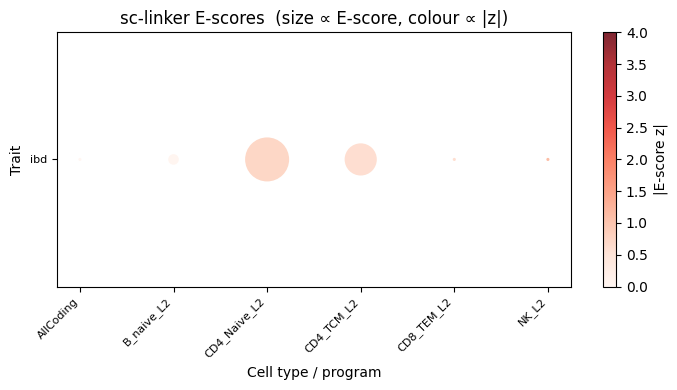

Top enrichments:
     program trait    E_score  E_score_z
CD4_Naive_L2   ibd  16.650182   0.728061
  CD4_TCM_L2   ibd   8.865241   0.605904
  B_naive_L2   ibd   0.895021   0.042090
   AllCoding   ibd   0.000000   0.000000
  CD8_TEM_L2   ibd -16.924056  -0.599301
       NK_L2   ibd -35.671857  -1.117085


In [5]:
import matplotlib.pyplot as plt
import numpy as np

abc_road = results_df[results_df["strategy"].str.startswith("ABC_Road")].copy()

if abc_road.empty:
    print("No ABC_Road results yet — run heritability first.")
else:
    programs = sorted(abc_road["program"].unique())
    traits   = sorted(abc_road["trait"].unique())
    prog2x   = {p: i for i, p in enumerate(programs)}
    trait2y  = {t: i for i, t in enumerate(traits)}

    fig, ax = plt.subplots(figsize=(max(6, len(programs) * 1.2), max(4, len(traits) * 0.8)))

    e_vals = abc_road["E_score"].clip(lower=0).to_numpy()
    z_vals = abc_road["E_score_z"].abs().to_numpy()
    x_vals = abc_road["program"].map(prog2x).to_numpy()
    y_vals = abc_road["trait"].map(trait2y).to_numpy()

    sc = ax.scatter(
        x_vals, y_vals,
        s=e_vals * 60 + 5,
        c=z_vals,
        cmap="Reds",
        vmin=0, vmax=max(4, z_vals.max()),
        alpha=0.85,
        edgecolors="none",
    )
    plt.colorbar(sc, ax=ax, label="|E-score z|")

    ax.set_xticks(range(len(programs)))
    ax.set_xticklabels(programs, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(traits)))
    ax.set_yticklabels(traits, fontsize=8)
    ax.set_xlabel("Cell type / program")
    ax.set_ylabel("Trait")
    ax.set_title("sc-linker E-scores  (size ∝ E-score, colour ∝ |z|)")
    plt.tight_layout()
    plt.savefig("sclinker_escore_bubble.png", dpi=150, bbox_inches="tight")
    plt.show()

    top = abc_road.nlargest(10, "E_score_z")
    print("Top enrichments:")
    print(top[["program","trait","E_score","E_score_z"]].to_string(index=False))